# 4EWA overview – Figure 1
Cross-shore SS and IG Hs at the event peak, one column per transect (B–E), one row per event. x = distance from shoreline (DEM-derived, from `bathymetry.ipynb`), left axis = Hs (log), right axis / sand fill = bathymetry along the transect. Filled = SS (0.04–0.25 Hz), open = IG (0.004–0.04 Hz); lines are least-squares fits of log10 Hs vs x.

In [33]:
import re, numpy as np, pandas as pd, matplotlib.pyplot as plt
from PIL import Image
from pyproj import Transformer
from scipy.ndimage import map_coordinates

# ---------------- INPUTS ----------------
KML      = '../ewa_Sensor_new.kml'
NOTES    = '../data/metadata/sensor_notes.csv'
DEM      = '../data/external/bathy/ncei19_n21x50_w158x25_2021v1.tif'
FIG_DIR  = '../figs/initial'
TRANSECTS = ['A','B','C','D','E']
KML_ID   = {'A':'6625','C':'6615','D':'6605','E':'6595'}   # SimpleData id of each transect line in the KML
B_SENSOR, B_BEARING = 'VB5', 336.0      # B has no KML line: run through VB5 along its shore-normal
B_OFFSHORE_M, B_ONSHORE_M = 6500., 3500.
DS       = 5.0                          # sample spacing along line (m)

XLIM=(-1500,0)

In [34]:
# DEM (GeoTIFF, EPSG:4326, pixel-is-area, upper-left corner from ModelTiepoint)
Image.MAX_IMAGE_PIXELS = None
im   = Image.open(DEM)
dx, dy = im.tag_v2[33550][:2]
lon0, lat0 = im.tag_v2[33922][3:5]
dem  = np.array(im, dtype='float32'); del im
def_nodata = dem < -9000
dem[def_nodata] = np.nan

# transect endpoints (offshore end -> onshore end), lon/lat
kml = open(KML).read()
ends = {}
for pm in re.findall(r'<Placemark.*?</Placemark>', kml, re.S):
    for T,i in KML_ID.items():
        if '>%s<'%i in pm and '<LineString' in pm:
            co = re.search(r'<coordinates>(.*?)</coordinates>', pm, re.S).group(1).split()
            co = np.array([[float(v) for v in p.split(',')] for p in co])
            ends[T] = (co[0,:2], co[-1,:2])
notes = pd.read_csv(NOTES)


In [35]:
to_xy = Transformer.from_crs(4326, 32604, always_xy=True)
nm, la, lo, dp = (notes.columns[2], notes.columns[4], notes.columns[5], notes.columns[8])
sens = notes.set_index(nm)

# B line: through VB5 along its shore-normal onshore bearing (no KML line for B)
x0, y0 = to_xy.transform(sens.loc[B_SENSOR, lo], sens.loc[B_SENSOR, la])
ux, uy = np.sin(np.radians(B_BEARING)), np.cos(np.radians(B_BEARING))
xyB = [(x0-B_OFFSHORE_M*ux, y0-B_OFFSHORE_M*uy), (x0+B_ONSHORE_M*ux, y0+B_ONSHORE_M*uy)]

prof = {}
for T in TRANSECTS:
    if T == 'B': p0, p1 = [np.array(p) for p in xyB]
    else:        p0, p1 = [np.array(to_xy.transform(*e)) for e in ends[T]]
    L = np.hypot(*(p1-p0)); s = np.arange(0, L+DS, DS)
    xy = p0 + np.outer(s/L, p1-p0)
    lon, lat = to_xy.transform(xy[:,0], xy[:,1], direction='INVERSE')
    col = (np.asarray(lon)-lon0)/dx - 0.5       # pixel centres
    row = (lat0-np.asarray(lat))/dx - 0.5
    z = map_coordinates(dem, [row, col], order=1, mode='nearest')
    # shoreline: last upward crossing of 0 m seaward of which the profile stays >= 0 for the next 100 m
    up = np.where((z[:-1] < 0) & (z[1:] >= 0))[0]
    k = [i for i in up if (z[i+1:i+1+int(100/DS)] >= 0).all()]
    ish = k[0] if k else up[-1]
    sshore = s[ish] + DS*(0-z[ish])/(z[ish+1]-z[ish])
    prof[T] = dict(s=s, x=s-sshore, z=z, p0=p0, p1=p1, L=L, ux=(p1-p0)/L)


In [36]:
# sensors projected onto each transect (cross-shore position and DEM depth there)
for T in TRANSECTS:
    P = prof[T]; P['sens'] = []
    for S in sens.index:
        if not (isinstance(S,str) and S[0] in 'VP' and S[1]==T): continue
        x, y = to_xy.transform(sens.loc[S, lo], sens.loc[S, la])
        sp = np.dot(np.array([x,y])-P['p0'], P['ux'])
        off = np.hypot(*(np.array([x,y])-P['p0']-sp*P['ux']))
        xs = sp - (P['s'] - P['x'])[0]
        zd = np.interp(xs, P['x'], P['z'])
        dnom = float(re.match(r'\s*-?[\d.]+', str(sens.loc[S, dp])).group()) if re.match(r'\s*-?[\d.]+', str(sens.loc[S, dp])) else np.nan
        P['sens'].append((S, xs, dnom, zd, off))


In [37]:
import xarray as xr
QC = '../data/processed/qc/'
sensors = {'A':['VA10'], 'B':['VB5','PB1','PB2'], 'C':['VC10','VC5','PC1'],
           'D':['VD10','VD5','PD1'], 'E':['VE10','VE7','VE4','PE1']}
# buoy peak times (UTC), from the project audit
events = {'Full record':('2026-07-19','2026-09-17'),
          '16 Aug (Lala)':('2026-08-11','2026-08-20'),
          '8 Sep (Lowell)':('2026-09-07','2026-09-09 23:00')}

def hs_band(S, f, f1, f2):
    m = (f>=f1)&(f<=f2)
    return 4*np.sqrt(np.trapz(S[:,m], f[m], axis=1))

spec = {}
for group in sensors.values():
    for s in group:
        d = xr.open_dataset(QC+f'{s}_spec.nc')
        f = d.frequency.values; S = d.Seta.values
        spec[s] = pd.DataFrame({'SS':hs_band(S,f,0.04,0.25), 'IG':hs_band(S,f,0.004,0.04), 'h':d.h_mean.values},
                               index=pd.to_datetime(d.time.values))

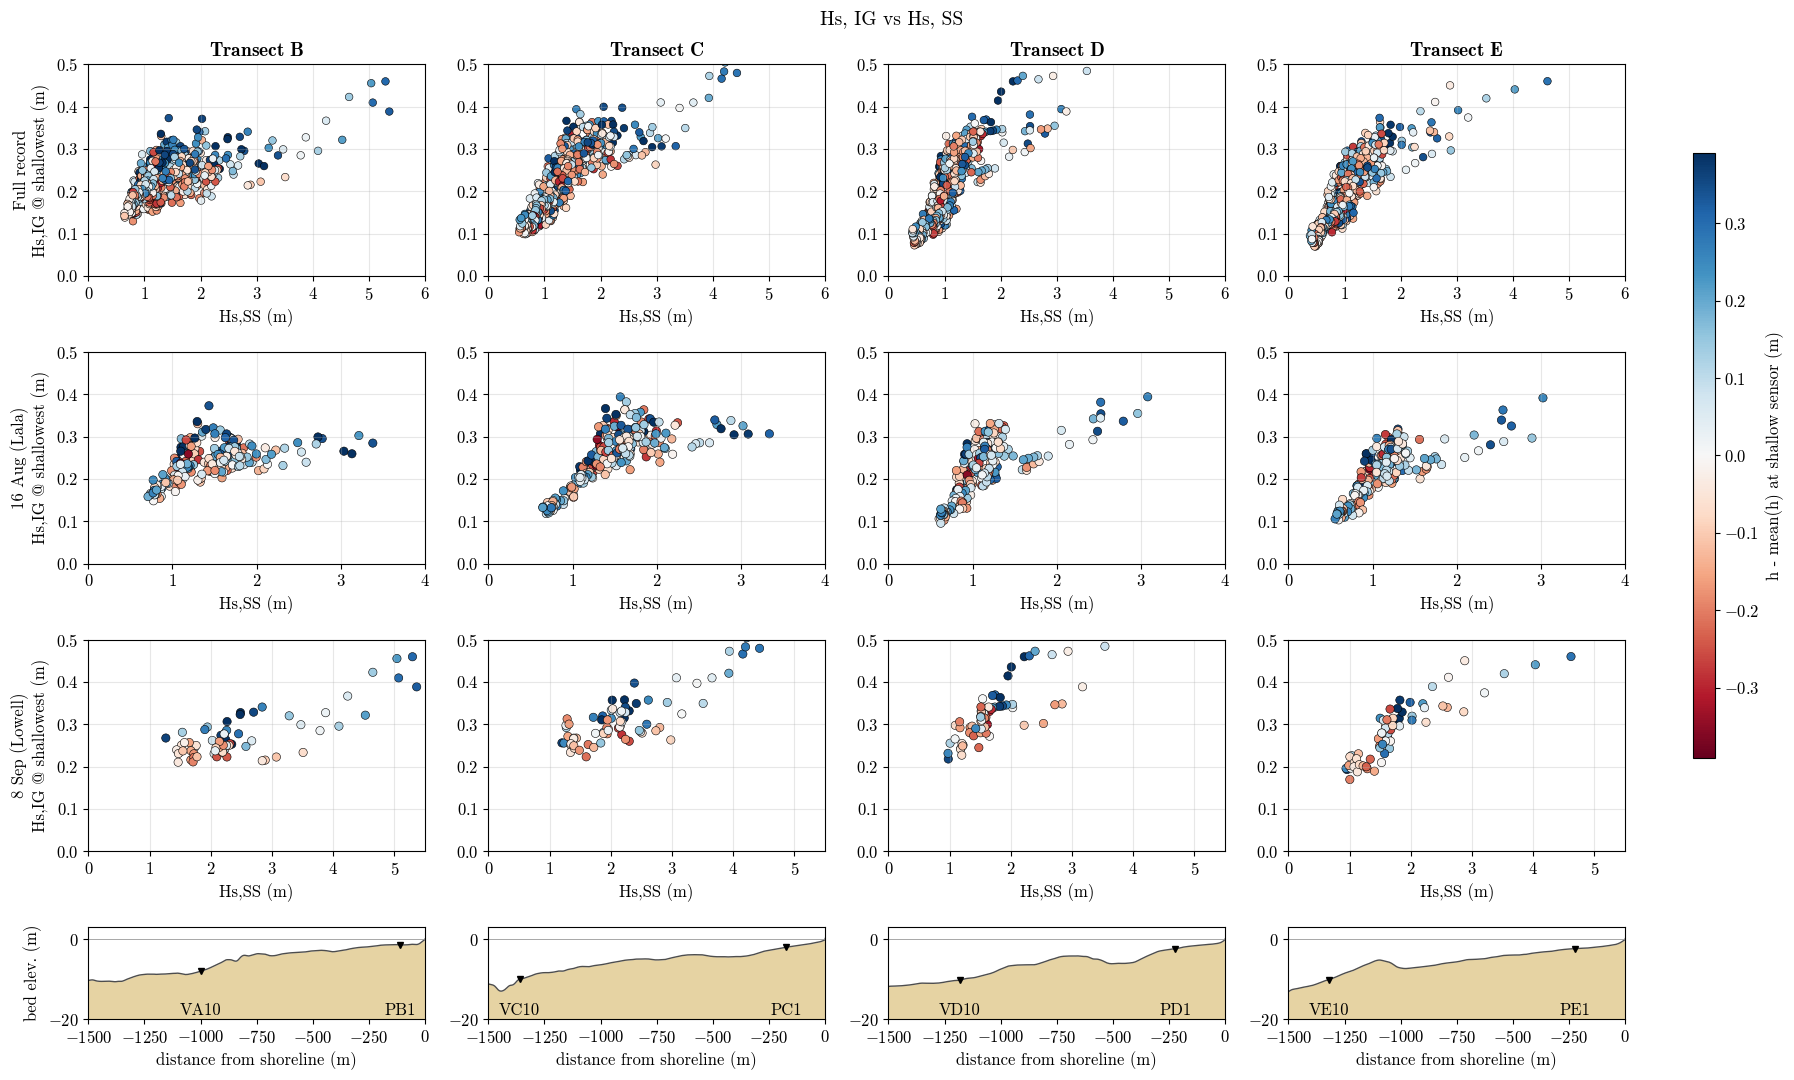

In [38]:
deep    = {'B':'VA10','C':'VC10','D':'VD10','E':'VE10'}    # deepest sensor per transect (SS)
shallow = {'B':'PB1','C':'PC1','D':'PD1','E':'PE1'}      # shallowest sensor per transect (IG)
SAND = '#E6D3A3'
xpos = {s:xs for T in prof for (s,xs,_,_,_) in prof[T]['sens']}
transects = ['B','C','D','E']; nE = len(events)
hbar = {p: spec[p]['h'].mean() for p in shallow.values()}   # full-record mean depth of each shallow sensor
hall = np.concatenate([(spec[p]['h']-hbar[p]).dropna().values for p in shallow.values()])
hmax = np.percentile(np.abs(hall),98); hlo, hhi = -hmax, hmax
plt.rcParams.update({'font.size':12,'axes.labelsize':12,'axes.titlesize':14,'xtick.labelsize':12,'ytick.labelsize':12})
fig, axs = plt.subplots(nE+1, 4, figsize=(18,11), gridspec_kw=dict(height_ratios=[3]*nE+[1.3]))
for i,(name,(t0,t1)) in enumerate(events.items()):
    for j,T in enumerate(transects):
        ax = axs[i,j]
        d = spec[deep[T]].loc[t0:t1]; s_ = spec[shallow[T]].loc[t0:t1]
        idx = d.index.intersection(s_.index)
        x = d.loc[idx,'SS']; y = s_.loc[idx,'IG']; h = s_.loc[idx,'h'] - hbar[shallow[T]]
        sc = ax.scatter(x, y, c=h, cmap='RdBu', s=30 if i==0 else 36, vmin=hlo, vmax=hhi, edgecolors='k', linewidths=0.4)
        ax.set_ylim(0, 0.5); ax.set_xlim(0, [6,4,5.5][i]); ax.grid(alpha=.3)
        if i==0: ax.set_title(rf'$\mathbf{{Transect\ {T}}}$')
        if j==0: ax.set_ylabel(f'{name}\nHs,IG @ shallowest (m)')
        ax.set_xlabel('Hs,SS (m)', fontsize=12)
for j,T in enumerate(transects):
    bx = axs[nE,j]; P = prof[T]; m = (P['x']>=XLIM[0]-50)&(P['x']<=50)
    bx.fill_between(P['x'][m], P['z'][m], -20, color=SAND, lw=0)
    bx.plot(P['x'][m], P['z'][m], color='0.3', lw=1); bx.axhline(0,color='0.6',lw=.6)
    for s in (deep[T], shallow[T]):
        bx.plot(xpos[s], np.interp(xpos[s],P['x'],P['z']), 'v', color='k', ms=5)
        bx.annotate(s,(xpos[s],-19),ha='center',fontsize=12)
    bx.set_ylim(-20,3); bx.set_xlim(XLIM); bx.set_xlabel('distance from shoreline (m)')
    if j==0: bx.set_ylabel('bed elev. (m)')
fig.suptitle(fontsize=14, t='Hs, IG vs Hs, SS')
plt.tight_layout(rect=(0,0,0.92,1))
cax = fig.add_axes([0.945,0.3,0.012,0.55]); fig.colorbar(sc, cax=cax, label="h - mean(h) at shallow sensor (m)")
import os; os.makedirs('../figs/overview',exist_ok=True)
plt.savefig('../figs/overview/hs_vs_hig.png',dpi=150)

## Figure 3 – Alongshore comparison at fixed depth lines
Event-peak Hs,SS and Hs,IG along the 10 m line (VA10, VC10, VD10, VE10) and the 5 m line (VB5, VC5, VD5, VE4), one column per event. Buoy (CDIP 238) Hs and Dp are the dashed reference. Alongshore position is approximate: sensor lat/lon projected on 80° true, origin at the array centroid. The Paros (PB1, PB2, PC1, PD1, PE1) are added as a third line; they only exist from 28 Jul (B, C) / 5 Aug (D, E). The aerial sensor map is georeferenced from the sensor pins and drawn faintly behind the data (rotated so alongshore is horizontal).

In [39]:
# alongshore position (m): project sensor UTM positions on 80 deg true
al = np.array([np.sin(np.radians(80)), np.cos(np.radians(80))])
cs = np.array([np.cos(np.radians(80)), -np.sin(np.radians(80))])   # cross-shore axis (onshore ~ north)
line10 = ['VA10','VC10','VD10','VE10']
line5  = ['VB5','VC5','VD5','VE4']
linep  = ['PB1','PB2','PC1','PD1','PE1']
allS = line10 + line5 + linep
xy = {s: np.array(to_xy.transform(sens.loc[s,lo], sens.loc[s,la])) for s in allS+['VE7']}
x0 = np.mean([xy[s] for s in line10+line5], axis=0)       # origin: centroid of the 8 V sensors
xal = {s: float(np.dot(xy[s]-x0, al)) for s in allS}
ev3 = {'Fausto':'2026-07-24 06:00', 'Lala':'2026-08-16 19:00', 'Lowell':'2026-09-08 11:00'}
for s in linep:
    d = xr.open_dataset(QC+f'{s}_spec.nc'); f = d.frequency.values; S = d.Seta.values
    spec[s] = pd.DataFrame({'SS':hs_band(S,f,0.04,0.25),'IG':hs_band(S,f,0.004,0.04),'h':d.h_mean.values}, index=pd.to_datetime(d.time.values)) if s not in spec else spec[s]
buoy = pd.read_csv('../data/metadata/cdip238_waves.csv', parse_dates=['time']).set_index('time')
def val(s, var, t):
    t = pd.Timestamp(t)
    return spec[s].loc[t,var] if t in spec[s].index else np.nan

# ---- georeference ewa_sensor_map.jpg from sensor pins (pixel positions read off the image, pin tips) ----
pins = {'VA10':(110,975),'VB5':(412,825),'PB1':(387,350),'PB2':(408,411),'VC5':(671,620),'PC1':(617,316),
        'VC10':(742,992),'VD5':(1441,565),'VD10':(1506,797),'PD1':(1373,257),'VE4':(1795,345),
        'VE7':(1838,576),'VE10':(1868,807),'PE1':(1751,182)}
sc_ = 2378/1999.                                  # pins were read off a 1999-px-wide view
P = np.array([[px*sc_,py*sc_,1] for px,py in pins.values()])
W = np.array([xy[s] for s in pins])               # UTM E,N
A,res,_,_ = np.linalg.lstsq(P, W, rcond=None)     # [px,py,1] -> [E,N]
print('map fit rms (m):', np.sqrt(np.mean((P@A-W)**2)))
from PIL import Image as PILImage
img = np.asarray(PILImage.open('../ewa_sensor_map.jpg').convert('RGB')).astype(float)/255
# output grid in (alongshore, cross-shore) metres
Aop = np.linalg.inv(np.vstack([A[:2].T, [0,0]]).T[:2,:2]) if False else None
gx = np.linspace(-1900, 1550, 900); gc = np.linspace(-950, 300, 400)   # region fully covered by the map
GX,GC = np.meshgrid(gx,gc)
E = x0[0] + GX*al[0] + GC*cs[0]; N = x0[1] + GX*al[1] + GC*cs[1]
M = A[:2].T                                       # [E,N] = M @ [px,py] + A[2]
Minv = np.linalg.inv(M)
pxy = np.einsum('ij,jkl->ikl', Minv, np.stack([E-A[2,0], N-A[2,1]]))
from scipy.ndimage import map_coordinates
warp = np.stack([map_coordinates(img[...,k], [pxy[1],pxy[0]], order=1, cval=np.nan) for k in range(3)], axis=-1)
warp = np.flipud(warp)                            # imshow origin upper: cross-shore increases downward

map fit rms (m): 1.2847117985486862


Fausto  10 m line      max/min Hs,SS = 1.81
Fausto  5 m line       max/min Hs,SS = 1.55
Lala    10 m line      max/min Hs,SS = 1.12
Lala    5 m line       max/min Hs,SS = 1.58
Lala    Paros (2-3 m)  max/min Hs,SS = 1.37
Lowell  10 m line      max/min Hs,SS = 1.29
Lowell  5 m line       max/min Hs,SS = 1.48
Lowell  Paros (2-3 m)  max/min Hs,SS = 1.39


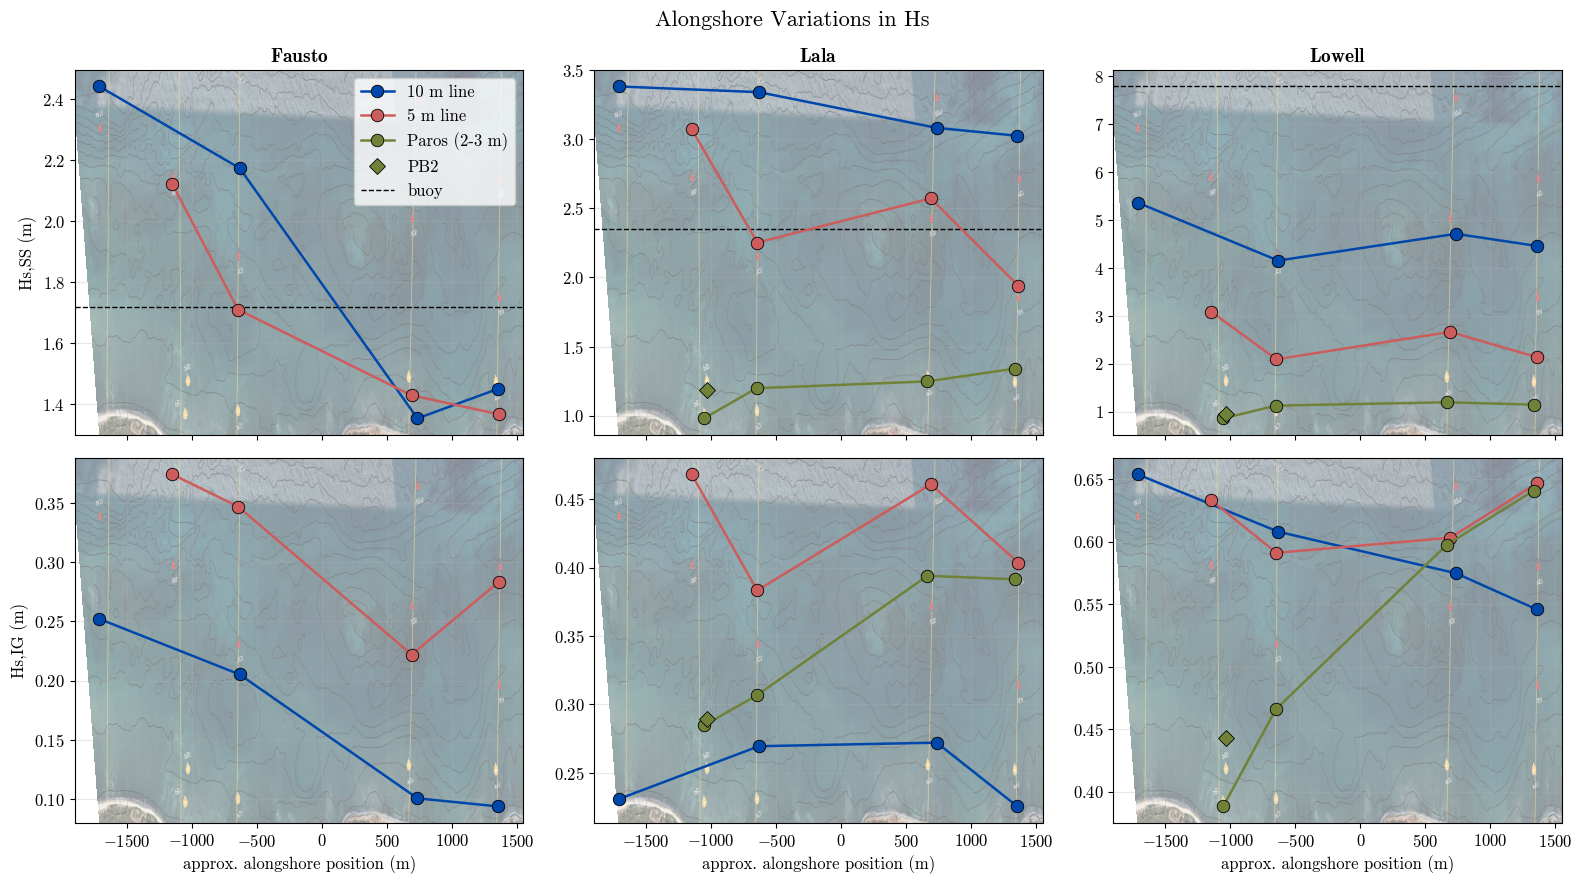

In [40]:
plt.rcParams.update({'font.size':12,'axes.labelsize':12,'axes.titlesize':14,'xtick.labelsize':12,'ytick.labelsize':12})
COBALT, RED, OLIVE = '#0047AB', 'indianred', '#708238'
lines = [(line10,COBALT,'10 m line'),(line5,RED,'5 m line'),(linep,OLIVE,'Paros (2-3 m)')]
rows = [('SS','Hs,SS (m)'),('IG','Hs,IG (m)')]
fig, axs = plt.subplots(2, 3, figsize=(16,9), sharex=True)
xl = (-1900, 1550)
for j,(name,tp) in enumerate(ev3.items()):
    t = pd.Timestamp(tp); bt = buoy.index[np.argmin(np.abs(buoy.index - t))]
    for i,(var,yl) in enumerate(rows):
        ax = axs[i,j]
        for line,col,lab in lines:
            pts = sorted((xal[s], val(s,var,t)) for s in line if s!='PB2')   # PB2 shown as a lone marker (same x as PB1)
            pts = [(x,y) for x,y in pts if np.isfinite(y)]
            if not pts: continue
            x,y = np.array(pts).T
            ax.plot(x,y,'-o',color=col,lw=1.8,ms=9,mec='k',mew=0.6,label=lab,zorder=3)
            if var=='SS' and len(y)>1: print(f'{name:7s} {lab:14s} max/min Hs,SS = {y.max()/y.min():.2f}')
        if np.isfinite(val('PB2',var,t)): ax.plot(xal['PB2'],val('PB2',var,t),'D',color=OLIVE,ms=8,mec='k',mew=0.6,zorder=3)
        if var=='SS': ax.axhline(buoy.loc[bt,'Hs'],color='k',ls='--',lw=1,label='buoy',zorder=2)
        ax.set_xlim(*xl); lo_,hi_ = ax.get_ylim()
        ax.imshow(warp, extent=[gx[0],gx[-1],lo_,hi_], aspect='auto', alpha=0.50, zorder=0)
        ax.set_xlim(*xl); ax.set_ylim(lo_,hi_)
        if i==0: ax.set_title('$\\mathbf{'+name.replace(' ','\\ ')+'}$')
        if j==0: ax.set_ylabel(yl)
        if i==1: ax.set_xlabel('approx. alongshore position (m)')
        ax.grid(alpha=.3)
from matplotlib.lines import Line2D
handles = [Line2D([],[],color=c,marker='o',ms=9,mec='k',mew=0.6,lw=1.8,label=l) for _,c,l in lines]
handles += [Line2D([],[],color=OLIVE,marker='D',ms=8,mec='k',mew=0.6,lw=0,label='PB2'),
            Line2D([],[],color='k',ls='--',lw=1,label='buoy')]
axs[0,0].legend(handles=handles, fontsize=12, loc='upper right')
fig.suptitle('Alongshore Variations in Hs', fontsize=16)
plt.tight_layout()
plt.savefig('../figs/overview/fig3_alongshore.png',dpi=150)